<img src="https://github.com/lid-ufpa/genial/blob/main/assets/genial-logo-banner-dark.png?raw=true" style="width:100%; height:auto;">

# **Aula 2 - Algoritmos Genéticos (AGs)**


Seja bem vindo(a) ao curso **Genetic and Evolutionary Nature-Inspired ALgorithms (GENIAL)**.

Nesta segunda aula, vamos explorar a fundo os Algoritmos Genéticos, conceituar os seus componentes básicos, descrever o seu processo iterativo e codificar um exemplo prático de AG para resolver um problema real.

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from genial.ga import GeneticAlgorithm

## 2.1 Introdução

**Algoritmos Genéticos (AGs)** são uma classe de algoritmos de busca e otimização inspirados pelo processo de seleção natural e evolução biológica. Propostos por John Holland na década de 1970, eles imitam os princípios da **genética** e da **sobrevivência do mais apto** para encontrar soluções aproximadas para problemas complexos, especialmente aqueles onde os métodos tradicionais de otimização falham ou são muito lentos.

Baseia-se na biologia evolutiva (Charles Darwin & Gregor Mendel), de onde é importado o seguinte vocabulário:

- Seleção natural
- Hereditariedade
- Indivíduo, cromossomo, gene e alelo
- Codificação
- Recombinação
- Mutação

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula02/lamarck-darwin.png?raw=true" style="width:100%; height:auto;">

A ideia central é evoluir uma **população** de soluções candidatas ao longo de várias **gerações**. A cada geração, os indivíduos mais "aptos" (as melhores soluções) têm maior probabilidade de serem selecionados para se reproduzir e transmitir suas características para a próxima geração. Através de **operadores genéticos** como cruzamento e mutação, novas soluções são criadas, explorando o espaço de busca de forma eficiente e convergindo, idealmente, para uma solução ótima ou próxima da ótima.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula02/evolutionary_algortihm.gif?raw=true" style="width:600px; height:auto;">

Eles são particularmente úteis em problemas de:

- Otimização (e.g., Problema do Caixeiro Viajante, Problema da Mochila).
- Busca em espaços de grande dimensão.
- Aprendizado de máquina (e.g., ajuste de hiperparâmetros, seleção de features).
- Design e engenharia.

<a href="https://www.youtube.com/watch?v=zIkBYwdkuTk" target="_blank">
  <img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula02/snake.gif?raw=true" style="width:600px; height:auto;">
</a>

AGs diferem de métodos tradicionais em quatro pontos:

1. AGs trabalham com uma **codificação do conjunto de parâmetros**, e não diretamente com os parâmetros.
2. AGs buscam em uma **população de pontos**, não em um único ponto.
3. AGs usam **somente informação da função objetivo**, sem necessitar de derivadas ou outro conhecimento auxiliar.
4. AGs usam **regras de transição probabilísticas**, ao invés de regras determinísticas.

---

## 2.2 Estrutura de um Algoritmo Genético

Para compreender a estrutura básica de um Algoritmo Genético (AG), começamos com um problema simples: encontrar o **máximo** da função quadrática $y = x^2$, onde $x$ varia entre 0 e 31.  

O gráfico abaixo mostra o formato parabólico da função, destacando o valor máximo $y = 961$, obtido quando $x = 31$.

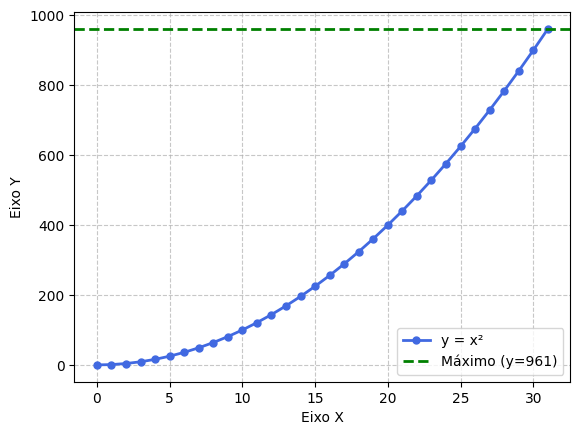

In [2]:
x = [i for i in range(32)]
y = [i**2 for i in x]

plt.plot(x, y, marker='o', linestyle='-', linewidth=2, color="royalblue", markersize=5, label="y = x²")
plt.axhline(max(y), color='green', linewidth=2, linestyle='--', label=f"Máximo (y={max(y)})")
plt.xlabel("Eixo X")
plt.ylabel("Eixo Y")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### 2.2.1 Indivíduo (cromossomo)

Um **indivíduo** representa uma **solução candidata** para o problema de otimização. Em analogia biológica, ele é chamado de **cromossomo**, composto por **genes** que armazenam os valores ou características de cada variável da solução.

Os cromossomos são análogos às estruturas genéticas naturais: cada **gene** corresponde a um elemento da solução, podendo assumir valores chamados **alelos**, enquanto sua **posição** é denominada **locus**. O conjunto completo de cromossomos codificados forma o **genótipo**, e as soluções representadas após a decodificação formam o **fenótipo**. Essa distinção entre genótipo (que representa a codificação) e fenótipo (que representa a decodificação) é fundamental para entendermos as etapas do algoritmo.

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula02/cromossomo.png?raw=true" style="width:100%; height:auto;">

O processo de **codificação** consiste em traduzir os parâmetros do problema em uma estrutura manipulável pelo AG, o cromossomo. O processo inverso, de **decodificação**, transforma o cromossomo novamente em uma solução concreta, a ser avaliada pela função objetivo. Essa transformação entre os espaços pode ser de três tipos:

- **Um-para-um:** cada codificação representa exatamente uma solução.
- **Um-para-muitos:** múltiplos cromossomos representam a mesma solução (há redundância).
- **Muitos-para-um:** uma codificação representa um conjunto de soluções (usado em representações indiretas que exigem um decodificador adicional).

Para o exemplo da parábola $y = x^2$ , cada cromossomo binário representa uma possível posição no eixo $x$, e os operadores genéticos permitem que a população evolua em direção ao valor máximo $x = 31, y = 961$.

Assim, o **espaço de busca** (representado pelos 32 cromossomos possíveis de 5 bits) é explorado por meio de **operações sobre as cadeias binárias**, não diretamente sobre os valores numéricos. Isso reflete a principal diferença dos AGs em relação aos métodos tradicionais de busca: os AGs **operam sobre representações codificadas** e não diretamente sobre as variáveis do problema, o que lhes confere robustez em espaços complexos e multimodais.

Vamos criar uma função `dec_to_bin()` que realiza a codificação dos valores numéricos do problema da parábola em uma cadeia binária de 5 bits.

In [3]:
def dec_to_bin(x, bits=5):
    return format(x, f'0{bits}b')

cromossomo = dec_to_bin(19)
cromossomo

'10011'

De maneira análoga, vamos criar a função inversa `bin_to_dec()` que transforma a cadeia binária em um valor numérico.

In [4]:
def bin_to_dec(b):
    return int(b, 2)

x = bin_to_dec(cromossomo)
x

19

### 2.2.2 Gene

O **gene** é a menor unidade de informação em um cromossomo, representando um atributo ou característica da solução. Cada gene ocupa uma posição fixa, chamada *locus*, e pode assumir diferentes valores possíveis, chamados **alelos**, que definem o estado da característica naquele ponto.

Os genes formam a **estrutura linear da representação**, sendo manipulados pelos operadores genéticos de seleção, cruzamento e mutação para produzir variações na população. Assim, a **combinação dos genes** de um indivíduo define completamente o comportamento da solução no espaço de busca.

Vamos destacar os locus e alelos do cromossomo para o fenótipo anterior.

In [5]:
for i, gene in enumerate(cromossomo):
    print(f"O gene no locus {i} assume o alelo {gene}")

O gene no locus 0 assume o alelo 1
O gene no locus 1 assume o alelo 0
O gene no locus 2 assume o alelo 0
O gene no locus 3 assume o alelo 1
O gene no locus 4 assume o alelo 1


### 2.2.3 População

A **população** é o conjunto de soluções candidatas (ou cromossomos) avaliadas em cada geração. Os AGs se diferenciam dos métodos tradicionais por operarem sobre uma população de pontos, em vez de um único ponto do espaço de busca. Essa abordagem aumenta a robustez e reduz a chance de aprisionamento em ótimos locais, pois múltiplas regiões do espaço são exploradas simultaneamente.

O papel da população é fornecer **diversidade** para o processo evolutivo. Cada geração contém indivíduos com desempenhos variados, permitindo a combinação de características vantajosas por meio dos operadores genéticos. Ele distingue dois objetivos complementares: **exploration** (buscar novas regiões do espaço) e **exploitation** (refinar boas soluções).

Ao manter uma coleção de soluções, os AGs podem aplicar seleção e recombinação de forma estatística, simulando o comportamento de populações naturais. Em essência, cada geração representa uma amostra adaptativa do espaço de busca, cujo perfil tende a se concentrar gradualmente em regiões de maior aptidão.


Vamos usar uma semente aleatória (_seed_) para que o mesmo conjunto de soluções iniciais seja reproduzido em diferentes execuções, o que é útil para experimentação controlada e comparação de resultados.

In [6]:
random.seed(42)

Cada número inteiro entre 0 e 31 representa um fenótipo, um valor possível de $x$ no domínio do problema. Construímos uma população inicial composta por 10 indivíduos, cada um representado por um número inteiro no intervalo [0, 31].

In [7]:
tamanho_populacao = 10

xs = []

for i in range(tamanho_populacao):
    xs.append(random.randint(0, 31))

xs

[7, 1, 17, 15, 14, 8, 6, 5, 27, 2]

Em seguida, cada indivíduo é codificado como uma sequência binária de 5 genes (bits), que formam o cromossomo.

In [8]:
populacao = []

for i in range(tamanho_populacao):
    cromossomo = dec_to_bin(xs[i])
    populacao.append(cromossomo)

populacao

['00111',
 '00001',
 '10001',
 '01111',
 '01110',
 '01000',
 '00110',
 '00101',
 '11011',
 '00010']

Para fins didáticos, a população é organizada em um DataFrame, onde cada linha representa um indivíduo e as colunas representa o valor do fenótipo, do genótipo e cada um dos 5 genes. Essa forma vetorial é a forma convencional de representar cromossomos em memória, pois permite a análise direta de cada posição (gene) e facilita a aplicação dos operadores evolutivos.

In [9]:
# criando um DataFrame com as colunas x e cromossomo
df_populacao = pd.DataFrame({"x": xs, "Cromossomo": populacao})

# adicionando colunas para cada gene
for i in range(5):
    df_populacao[f"Gene_{i}"] = df_populacao["Cromossomo"].apply(lambda x: x[i])

df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4
0,7,00111,0,0,1,1,1
1,1,00001,0,0,0,0,1
2,17,10001,1,0,0,0,1
3,15,01111,0,1,1,1,1
4,14,01110,0,1,1,1,0
5,8,01000,0,1,0,0,0
6,6,00110,0,0,1,1,0
7,5,00101,0,0,1,0,1
8,27,11011,1,1,0,1,1
9,2,00010,0,0,0,1,0


### 2.2.4 Função de aptidão (_fitness_)

A **função de aptidão** é o mecanismo pelo qual cada indivíduo da população é avaliado. Ela mede a qualidade ou adaptação da solução representada pelo cromossomo em relação ao problema.

O _fitness_ é uma medida de “utilidade ou adequação” do indivíduo: quanto maior o valor da função, maior a chance de o cromossomo ser selecionado para reprodução. O _fitness_ também atua como um guia do processo evolutivo em direção às melhores regiões do espaço de busca.  

A função de aptidão e a função objetivo estão intimamente relacionadas, mas não são exatamente a mesma coisa:

- Função objetivo: define matematicamente o problema a ser otimizado e pertence ao domínio do problema, associando a cada solução do espaço de busca um valor real que descreve sua qualidade.
- Função fitness: é o mecanismo interno de avaliação utilizado pelo AG, podendo ser igual ou derivado da função objetivo, por exemplo, somando ou ponderando múltiplos objetivos para formar um único valor de aptidão em problemas multiobjetivo.

No caso do problema da parábola $y = x^2$, a função de aptidão é diretamente igual à função objetivo.

In [10]:
def fitness_quadratico(x):
    return x**2

Aqui, adicionamos uma nova coluna `Fitness` ao DataFrame, armazenando a aptidão de cada indivíduo. Esse processo de avaliação populacional é uma das etapas centrais do ciclo evolutivo: todos os indivíduos são medidos sob o mesmo critério, de modo que a seleção natural artificial possa agir sobre aqueles com melhor desempenho, reproduzindo-os com maior probabilidade nas próximas gerações.


In [11]:
df_populacao["Fitness"] = df_populacao["x"].apply(fitness_quadratico)
df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,7,00111,0,0,1,1,1,49
1,1,00001,0,0,0,0,1,1
2,17,10001,1,0,0,0,1,289
3,15,01111,0,1,1,1,1,225
4,14,01110,0,1,1,1,0,196
5,8,01000,0,1,0,0,0,64
6,6,00110,0,0,1,1,0,36
7,5,00101,0,0,1,0,1,25
8,27,11011,1,1,0,1,1,729
9,2,00010,0,0,0,1,0,4


Após o cálculo da aptidão, os indivíduos são classificados em ordem decrescente de fitness (pois o problema é de maximização), o que facilita a aplicação do operador de seleção nas próximas etapas. Essa ordenação seguida de seleção garante a sobrevivência dos mais aptos, indivíduos com maior valor de fitness têm mais chances de deixar descendentes, perpetuando suas características genéticas, também conhecido como princípio da **pressão seletiva**.

In [12]:
df_populacao = df_populacao.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
df_populacao

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,27,11011,1,1,0,1,1,729
1,17,10001,1,0,0,0,1,289
2,15,01111,0,1,1,1,1,225
3,14,01110,0,1,1,1,0,196
4,8,01000,0,1,0,0,0,64
5,7,00111,0,0,1,1,1,49
6,6,00110,0,0,1,1,0,36
7,5,00101,0,0,1,0,1,25
8,2,00010,0,0,0,1,0,4
9,1,00001,0,0,0,0,1,1


### 2.2.5 Geração

Uma **geração** corresponde a um ciclo completo do processo evolutivo: avaliação da população, seleção dos mais aptos e criação de uma nova população. Cada geração representa, portanto, uma **etapa de evolução** no tempo, um ponto da trajetória onde as soluções se transformam gradualmente em direção a regiões mais promissoras do espaço de busca.  

Dessa forma, um AG age como um processo iterativo, onde "os indivíduos mais aptos são copiados com maior probabilidade, de modo que as boas características se propaguem ao longo do tempo. Esse princípio, conhecido como a **sobrevivência dos mais aptos**, é a essência do mecanismo de adaptação, garantindo que o desempenho médio da população tenda a crescer a cada nova geração.

O conceito de geração é central não apenas nos AGs, mas em toda a **computação evolucionária**, onde a população é "avaliada, filtrada e substituída sucessivamente, num ciclo contínuo de melhora adaptativa". Assim, cada geração constitui um passo incremental de aprendizado coletivo, as soluções mais aptas sobrevivem, e as menos aptas são descartadas ou substituídas.

É importante salientar que esse processo cíclico cria uma **dinâmica evolutiva emergente**: o algoritmo não armazena conhecimento explicitamente, mas **aprende indiretamente** através da seleção e reprodução dos indivíduos mais bem avaliados. Com o passar das gerações, esse processo conduz a população a estados de melhor adaptação, reproduzindo o comportamento observado em sistemas naturais.

Para observar a evolução das soluções ao longo das gerações, podemos registrar os indivíduos mais aptos em cada etapa. A seguir, selecionamos os dois melhores cromossomos da população atual, que representam os indivíduos sobreviventes que, de acordo com a noção de sobrevivência dos mais aptos, possuem maior chance de influenciar as gerações futuras.

In [13]:
df_top2 = df_populacao.iloc[:2]
df_top2

,x,Cromossomo,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Fitness
0,27,11011,1,1,0,1,1,729
1,17,10001,1,0,0,0,1,289


Agora, simulamos um processo bem próximo ao AG, com a evolução ao longo de várias gerações. Em cada geração, uma nova população é criada e avaliada, armazenando-se os melhores indivíduos de cada etapa.

**Ainda não aplicamos cruzamento ou mutação**. A ideia é apenas observar o comportamento da aptidão média e dos melhores cromossomos ao longo do tempo.

In [14]:
n_geracoes = 30

pop_history = []
top_cromossomos = []

for g in range(n_geracoes):
    # criando uma nova população e calculando o fitness
    xs = [random.randint(0, 31) for _ in range(10)]
    df_populacao_atual = pd.DataFrame({"x": xs, "Cromossomo": [dec_to_bin(x) for x in xs]})
    df_populacao_atual["Fitness"] = df_populacao_atual["x"].apply(fitness_quadratico)
    df_populacao_atual = df_populacao_atual.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
    pop_history.append(df_populacao_atual)

    # guardando os dois melhores cromossomos
    df_top2 = df_populacao_atual.iloc[:2]
    top_cromossomos.append(df_top2)

# concatenando todos os melhores cromossomos e ordenando pelo fitness
df_tops = pd.concat(top_cromossomos).reset_index(drop=True)
df_tops = df_tops.sort_values(by="Fitness", ascending=False).reset_index(drop=True)
df_tops.head(10)

,x,Cromossomo,Fitness
0,31,11111,961
1,31,11111,961
2,31,11111,961
3,31,11111,961
4,31,11111,961
5,31,11111,961
6,31,11111,961
7,31,11111,961
8,30,11110,900
9,30,11110,900


---

## 2.3 Etapas do Algoritmo

<img src="https://github.com/lid-ufpa/genial/blob/main/aulas/images/aula02/fluxograma-ag.png?raw=true" style="width:1000px; height:auto;">

### 2.3.1 Inicialização

Na **inicialização** é criada a **população inicial**, ou seja, o conjunto de soluções candidatas que dará origem ao processo evolutivo. A inicialização deve garantir diversidade genética entre os indivíduos, pois a variabilidade inicial é essencial para que o processo de seleção e evolução seja eficaz. Portanto, essa etapa pode ser feita de forma **aleatória**, **heurística** ou **híbrida**, dependendo do conhecimento prévio sobre o problema.  

No problema proposto, encontrar o máximo da parábola $y = x^2$ para $x \in [0, 31]$, a inicialização consiste em gerar uma população de valores inteiros nesse intervalo e convertê-los em suas representações binárias de 5 bits, correspondentes aos cromossomos do AG, o que já foi expresso no DataFrame `df_populacao`.

In [15]:
class Solution:
    def __init__(self, x=None, cromossome=None):
        self.x = x if x is not None else bin_to_dec(cromossome)
        self.cromossome = cromossome if cromossome is not None else dec_to_bin(x)
        self.fitness = None

    def calculate_fitness(self, f):
        self.fitness = f(self.x)
        return self.fitness

    def __repr__(self):
        return f"Solution(x={self.x}, cromossome='{self.cromossome}')"
    
    def __str__(self):
        return self.__repr__()

In [16]:
def create_population(size):
    population = [Solution(random.randint(0, 31)) for _ in range(size)]
    return population

population = create_population(10)
population

[Solution(x=2, cromossome='00010'),
 Solution(x=22, cromossome='10110'),
 Solution(x=13, cromossome='01101'),
 Solution(x=15, cromossome='01111'),
 Solution(x=6, cromossome='00110'),
 Solution(x=22, cromossome='10110'),
 Solution(x=26, cromossome='11010'),
 Solution(x=9, cromossome='01001'),
 Solution(x=15, cromossome='01111'),
 Solution(x=10, cromossome='01010')]

### 2.3.2 Avaliação (cálculo do fitness)

A etapa de **avaliação** mede o desempenho de cada indivíduo da população, determinando o quanto cada solução é **adaptada** ao problema.  

No caso da parábola $y = x^2$, o valor de fitness é diretamente igual ao valor de $y$. Assim, a avaliação consiste em aplicar a função $f(x) = x^2$ a cada indivíduo da população.

In [17]:
for individual in population:
    individual.calculate_fitness(fitness_quadratico)

fitnesses = [ind.fitness for ind in population]
fitnesses

[4, 484, 169, 225, 36, 484, 676, 81, 225, 100]

### 2.3.3 Seleção dos pais

A **seleção** é o processo responsável por escolher quais indivíduos da população atual terão maior influência na próxima geração. As soluções com maior valor de aptidão são copiadas com probabilidade proporcional ao seu desempenho, resultando na propagação de boas características genéticas ao longo das gerações.  

A seleção atua como **filtro adaptativo**, preservando os indivíduos mais promissores e permitindo a substituição gradual dos menos aptos. Esse processo de filtragem garante que o algoritmo direcione o esforço de busca para regiões de maior qualidade no espaço de soluções.  

#### 2.3.3.1 Seleção dos pais por torneio

Os indivíduos são selecionados aleatoriamente para um "ring". O indivíduo com o melhor valor de aptidão é selecionado como pai.

In [18]:
def ring_selection(population, ring_size=3):
    selected_for_ring = random.sample(population, ring_size * 2)

    ring_1 = selected_for_ring[:ring_size]
    ring_2 = selected_for_ring[ring_size:]

    ring_1 = sorted(ring_1, key=lambda ind: ind.fitness, reverse=True)
    ring_2 = sorted(ring_2, key=lambda ind: ind.fitness, reverse=True)

    parents = [ring_1[0], ring_2[0]]
    return parents

parents = ring_selection(population, ring_size=3)
parents

[Solution(x=26, cromossome='11010'), Solution(x=22, cromossome='10110')]

#### 2.3.3.2 Seleção dos pais por roleta

A probabilidade de um indivíduo ser selecionado é proporcional ao seu fitness.

In [19]:
def roulette_selection(population):
    total_fitness = sum(ind.fitness for ind in population)
    selection_probs = [ind.fitness / total_fitness for ind in population]

    parents = np.random.choice(population, size=2, replace=False, p=selection_probs)
    return parents.tolist()

parents = roulette_selection(population)
parents

[Solution(x=26, cromossome='11010'), Solution(x=15, cromossome='01111')]

### 2.3.4 Cruzamento

O **cruzamento** (ou *crossover*) é o operador genético responsável por combinar informações de dois indivíduos para gerar novos descendentes.

Inspirado no processo biológico de reprodução sexual, o cruzamento permite a **recombinação de genes** de diferentes cromossomos, criando soluções potencialmente melhores a partir de boas soluções existentes.  

O cruzamento atua como um "intercâmbio estruturado e aleatório de informação entre soluções", cujo objetivo é gerar novas combinações genéticas sem destruir completamente as boas estruturas existentes (os chamados **esquemas vantajosos**). O operador deve preservar **subestruturas curtas e de alto desempenho**, pois são elas que se propagam exponencialmente ao longo das gerações, sustentando o princípio de evolução cumulativa.  

#### 2.3.4.1 Cruzamento por ponto de corte

No problema da parábola $y = x^2$, podemos implementar um cruzamento simples de **um ponto de corte** (*one-point crossover*), onde parte dos bits do primeiro pai é combinada com os bits restantes do segundo (e vice-versa), formando até dois novos cromossomos descendentes.

In [20]:
def cut_crossover(parent1, parent2, cut_point=None):
    if cut_point is None:
        cut_point = random.randint(1, len(parent1.cromossome) - 1)

    child1_cromossome = parent1.cromossome[:cut_point] + parent2.cromossome[cut_point:]
    child2_cromossome = parent2.cromossome[:cut_point] + parent1.cromossome[cut_point:]

    child1 = Solution(cromossome=child1_cromossome)
    child2 = Solution(cromossome=child2_cromossome)

    return child1, child2

child1, child2 = cut_crossover(parents[0], parents[1])
child1, child2

(Solution(x=27, cromossome='11011'), Solution(x=14, cromossome='01110'))

#### 2.3.4.2 Cruzamento uniforme

Outro tipo de cruzamento comum é gerar um vetor binário a partir de uma distribuição uniforme, e selecionar os genes de cada pai com base na codificação deste vetor.

In [21]:
def uniform_crossover(parent1, parent2):
    uniform_crossover_vector = [random.choice([0, 1]) for _ in range(len(parents[0].cromossome))]

    child_cromossome = ""

    for i in range(len(uniform_crossover_vector)):
        if uniform_crossover_vector[i] == 0:
            child_cromossome += parent1.cromossome[i]
        else:
            child_cromossome += parent2.cromossome[i]

    child = Solution(cromossome=child_cromossome)

    return child

uniform_child = uniform_crossover(parents[0], parents[1])
uniform_child


Solution(x=27, cromossome='11011')

### 2.3.5 Mutação

A **mutação** é o operador genético responsável por introduzir **novas variações aleatórias** no material genético dos indivíduos. Inspirada no processo biológico de mutações genéticas, ela altera ocasionalmente o valor de um ou mais genes, garantindo que o algoritmo continue explorando regiões ainda não visitadas do espaço de busca.  

Dessa forma, a mutação age como um operador que “**introduz pequenas perturbações aleatórias nos cromossomos, impedindo que o processo evolutivo fique preso a soluções locais**”.  
Embora menos frequente que o cruzamento, ela desempenha um papel crucial na **manutenção da diversidade genética** e na prevenção da **convergência prematura** da população.

Enquanto o cruzamento combina estruturas já existentes, a mutação permite “**explorar novas regiões do espaço de busca por meio de modificações aleatórias controladas**”.  
Ela atua como um mecanismo de **equilíbrio** entre exploração e intensificação: pequenas mutações ajudam o algoritmo a escapar de ótimos locais sem perder o foco na busca global.  

#### 2.3.5.1 Bit flip

No problema da parábola $y = x^2$, podemos escolher aleatoriamente um ou mais locus e modificar o bit em um cromossomo com uma pequena probabilidade. Essa operação garante que novas combinações de genes possam surgir, mesmo que o cruzamento sozinho não as produza.

In [22]:
def bit_flip_mutation(individual, mutation_rate=0.1):
    new_cromossome = ""

    for gene in individual.cromossome:
        if random.random() < mutation_rate:
            new_gene = '1' if gene == '0' else '0'
        else:
            new_gene = gene
        new_cromossome += new_gene

    mutated_individual = Solution(cromossome=new_cromossome)
    return mutated_individual

bit_flipped_child = bit_flip_mutation(parents[0], mutation_rate=0.2)
bit_flipped_child

Solution(x=26, cromossome='11010')

#### 2.3.5.2 Permutação

Outra estratégia é escolher dois locus aleatórios e permutar seus valores.

In [23]:
def permutation_mutation(individual):
    cromossome_list = list(individual.cromossome)
    idx1, idx2 = random.sample(range(len(cromossome_list)), 2)
    cromossome_list[idx1], cromossome_list[idx2] = cromossome_list[idx2], cromossome_list[idx1]
    new_cromossome = ''.join(cromossome_list)
    mutated_individual = Solution(cromossome=new_cromossome)
    return mutated_individual

permutated_child = permutation_mutation(parents[0])
permutated_child

Solution(x=22, cromossome='10110')

### 2.3.6. Seleção dos sobreviventes

A **seleção dos sobreviventes** define quais indivíduos permanecerão na população após o processo de reprodução, cruzamento e mutação. Enquanto a seleção inicial escolhe quem reproduz, esta etapa determina quem continua vivo para compor a próxima geração. Ela é, portanto, o elo que conecta o final de um ciclo evolutivo ao início do próximo. Esse mecanismo assegura a continuidade genética das boas soluções e o avanço progressivo do desempenho médio da população.

No exemplo da parábola $y = x^2$, podemos implementar uma estratégia simples de elitismo, em que os indivíduos mais aptos da geração anterior são preservados na nova população.

#### 2.3.6.1 Seleção geracional

A seleção dos sobreviventes pode ser feita de forma **geracional**, substituindo toda a população antiga pela nova.

In [24]:
new_population = []

new_population.append(child1)
new_population.append(child2)
new_population.append(bit_flipped_child)
new_population.append(permutated_child)

new_population

[Solution(x=27, cromossome='11011'),
 Solution(x=14, cromossome='01110'),
 Solution(x=26, cromossome='11010'),
 Solution(x=22, cromossome='10110')]

#### 2.3.6.2 Seleção elitista

A seleção também pode ser feita de forma **elitista**, quando alguns dos melhores indivíduos são preservados automaticamente para não se perderem com o processo de variação.

In [25]:
population.append(child1)
population.append(child2)
population.append(bit_flipped_child)
population.append(permutated_child)

for individual in population:
    individual.calculate_fitness(fitness_quadratico)

new_population = sorted(population, key=lambda ind: ind.fitness, reverse=True)[:10]
new_population

[Solution(x=27, cromossome='11011'),
 Solution(x=26, cromossome='11010'),
 Solution(x=26, cromossome='11010'),
 Solution(x=22, cromossome='10110'),
 Solution(x=22, cromossome='10110'),
 Solution(x=22, cromossome='10110'),
 Solution(x=15, cromossome='01111'),
 Solution(x=15, cromossome='01111'),
 Solution(x=14, cromossome='01110'),
 Solution(x=13, cromossome='01101')]

### 2.3.7. Critério de parada

O **critério de parada** define o momento em que o algoritmo genético deve encerrar sua execução. Como os AGs são processos iterativos e estocásticos, é necessário estabelecer uma condição que indique quando a evolução atingiu um ponto satisfatório, seja por convergência das soluções, limitação de recursos ou ausência de melhorias significativas.  

Por se tratar de um processo de busca adaptativo, o AG não precisa necessariamente atingir o ótimo global para ser considerado bem-sucedido: a melhoria contínua das soluções já caracteriza um comportamento adaptativo robusto
.  
Assim, o critério de parada deve refletir **o equilíbrio entre tempo de execução e qualidade das soluções**.

Alguns dos critérios mais comuns:  
- **Número máximo de gerações:** o algoritmo é interrompido após certo número de iterações;  
- **Estagnação:** o algoritmo é encerrado se não houver melhoria significativa no melhor fitness por um determinado número de gerações consecutivas;  
- **Tempo limite:** útil em contextos de tempo real ou processamento restrito;  
- **Qualidade do resultado:** quando o fitness atinge um valor satisfatório pré-definido.  

O critério de parada deve ser consistente com o objetivo do experimento. Geralmente, em pesquisas teóricas, usa-se número fixo de gerações, enquanto que em aplicações práticas, prioriza-se a convergência ou o desempenho obtido. Além disso, o **registro do histórico de fitness** é essencial para avaliar se o algoritmo atingiu estabilidade ou se ainda há potencial de melhora.

No caso do problema da parábola $y = x^2$, podemos adotar um critério simples: interromper o algoritmo quando atingir um número máximo de gerações ou quando o melhor indivíduo alcançar o valor ótimo conhecido $y = 961$.

In [26]:
max_generations = 50
population_size = 10
optimal_value = 961

best_solutions = []

for generation in range(max_generations):
    # iniciando uma nova população
    population = create_population(population_size)

    # calculando os fitnesses
    for individual in population:
        individual.calculate_fitness(fitness_quadratico)

    # seleção dos pais
    parents = roulette_selection(population)

    # cruzamento
    child_1, child_2 = cut_crossover(parents[0], parents[1])

    # mutação
    bit_flipped_child = bit_flip_mutation(parents[0], mutation_rate=0.2)

    # criando nova população com seleção elitista
    population.append(child_1)
    population.append(child_2)
    population.append(bit_flipped_child)
    for individual in population:
        individual.calculate_fitness(fitness_quadratico)

    population = sorted(population, key=lambda ind: ind.fitness, reverse=True)[:population_size]

    # critério de parada
    if population[0].fitness >= optimal_value:
        break

print(f"Ótimo alcançado na geração {generation + 1}: {population[0]} com fitness {population[0].fitness}")

Ótimo alcançado na geração 6: Solution(x=31, cromossome='11111') com fitness 961



---

## 2.4 Definição Formal

Dado um espaço de busca $S$ e uma função de aptidão $f: S \to \mathbb{R}$, o objetivo é encontrar uma solução $s^* \in S$ tal que $f(s^*)$ seja o valor máximo ou mínimo da função.

Assim, para um problema de minimização:
$$
s^* = \arg \min_{s \in S} f(s),
$$
Para um problema de maximização
$$
s^* = \arg \max_{s \in S} f(s),
$$

O processo pode ser resumido da seguinte forma:

1. Inicializar uma população $P_{0} = \{s1, s_{2}, \dots, s_{n}\}$ onde cada $s_{i} \in S$.
2. Para $t = 0, 1, 2, \dots, t_{max}$ faça:
	- Avaliar $P_{t}$: calcular $f(s_{i})$ para todo $s_{i} \in S$.
	- Selecionar pais $P'_{t}$ de $P_{t}$ com base em seu fitness.
	- Aplicar cruzamento em pares de $P'_{t}$ para gerar um conjunto de filhos $C_{t}$.
	- Aplicar mutação em indivíduos de $C_{t}$ com uma probabilidade $p_{m}$.
	- Criar nova população $P_{t+1}$ substituindo os indivíduos de $P_{t}$ pelos filhos de $C_{t}$.
3. Retornar o melhor indivíduo encontrado.



--- 

## 2.5 Exemplo: Aplicação de um AG ao Problema da Mochila

Nesta seção, vamos aplicar os conceitos aprendidos sobre AGs para resolver o problema da mochila (KSP). 

O problema da mochila consiste em um conjunto de objetos, em que cada um desses objetos possui um valor e um peso específico, e o nosso objetivo é selecionar o subconjunto de objetos que **maximiza** a soma dos valores mas que o peso total não seja maior que o peso máximo suportado pela mochila. 

No problema da mochila, é escolhido a **representação binária** dos indivíduos, ou seja, cada um deles é formado por **lista composta por uma sequência de 0s e 1s**. Nesta representação:

- O dígito `1` na posição `i` significa que o item `i` foi colocado na mochila.
- O dígito `0` na posição `i` significa que o item `i` não foi colocado na mochila. 

A função _fitness_ usada para medir a qualidade de cada solução (indivíduo) é basicamente a soma dos valores dos objetos presentes na mochila. Contudo, caso o peso total dos objetos ultrapasse o peso máximo suportado pela mochila é aplicada uma **penalidade** ao valor de _fitness_.

Para implementar essa lógica, vamos representar os valores e os pesos como duas listas separadas, em que o índice da lista corresponde a um objeto, o seu valor e o seu peso.

- `valores[i]`: armazena o **valor do i-ésimo objeto**.
- `peso[i]`: armazena o **peso do i-ésimo objeto**.

Por exemplo, considere um problema da mochila com 3 objetos, definidos da seguinte forma:

- Valores: `[5, 8, 15]`
- Pesos: `[10, 14, 20]`

Um indivíduo possível pode ser representado pelo valor `[1, 0, 1]`. Em que:

- O primeiro objeto foi incluído.
- O segunda objeto foi deixado de fora.
- O terceiro objeto foi incluído.

Assim, o valor de _fitness_ e o peso total dos objetos dessa solução é:

- Peso total: $(1 \times 10) + (0 \times 14) + (1 \times 20) = 10 + 20 = 30$
- _Fitness_: $(1 \times 5) + (0 \times 8) + (1 \times 15) = 5 + 15 = 20$

Agora em uma visão mais formal, o problema pode ser descrito da seguinte maneira: existe um conjunto $S$ com $N$ objetos, sendo cada objeto $Obj_{i}$ caracterizado por um peso $P_{i}$ e por um valor $V_{i}, i = 1, ..., N$ (todos os pesos e os valores são positivos). Além disso, a mochila tem uma capacidade $C > 0$. O objetivo é encontrar um subconjunto de objetos que satisfaça as seguintes condições:
$$
\max \sum_{i=1}^{N} x_{i} \times V_{i}
$$
$$
\text{sujeito a} \sum_{i=1}^{N} x_{i} \times P_{i} \le C
$$
Nas equações acima, $x_{i} ∈ {0, 1}$ ($x_{i} = 1$ se o $Obj_{i}$ estiver na mochila, $x_{i} = 0$ caso contrário).


Agora, iremos codificar passo a passo a implementação do AG ao problema da mochila.

### 2.5.1 Definição dos parâmetros e hiperparâmetros

Primeiramente, precisamos definir as informações necessárias para o problema e para o algoritmo.

- Parâmetros do problema:
    - `VALORES` e `PESOS`: Listas que contêm o valor e o peso de cada item.
    - `PESO_MAXIMO`: Peso máximo suportado pela mochila.

- Hiperparâmetros do algoritmo:
    - `TAMANHO_DA_POPULACAO`: Quantos indivíduos teremos por população.
    - `TAMANHO_DO_INDIVIDUO`: Quantos genes teremos por indivíduo, cada gene corresponde a um item.
    - `GERACOES`: Quantidade de ciclos executados pelo o algoritmo.
    - `TAXA_DE_MUTACAO`: A probabilidade de mutação de cada gene sofrer de forma aleatória.

In [27]:
TAMANHO_DA_POPULACAO = 1000
TAMANHO_DO_INDIVIDUO = 100
PESO_MAXIMO = 1550
TAXA_DE_MUTACAO = 0.001
GERACOES = 20

PESOS = [
    74, 16, 58, 35, 72, 15, 77, 52, 28, 63, 45, 19, 66, 40, 23, 81, 
    12, 50, 31, 68, 37, 54, 25, 79, 43, 60, 21, 48, 70, 33, 64, 27, 
    56, 39, 75, 18, 62, 47, 29, 76, 14, 53, 36, 67, 24, 49, 71, 32, 
    59, 42, 78, 17, 55, 38, 73, 20, 51, 69, 34, 61, 26, 57, 44, 80, 
    13, 65, 30, 46, 22, 63, 41, 11, 50, 77, 10, 54, 35, 72, 19, 48, 
    66, 31, 58, 45, 82, 15, 60, 37, 74, 28, 52, 69, 25, 47, 64, 33, 
    59, 43, 76, 21
]
VALORES = [
    91, 20, 81, 50, 76, 30, 85, 65, 44, 70, 60, 25, 88, 55, 33, 95, 
    18, 62, 42, 75, 51, 68, 39, 90, 58, 72, 29, 64, 82, 47, 78, 40, 
    71, 54, 89, 26, 77, 63, 45, 84, 22, 69, 52, 80, 37, 61, 83, 48, 
    73, 57, 92, 24, 67, 53, 86, 28, 66, 79, 49, 74, 41, 70, 59, 94, 
    19, 76, 46, 60, 34, 75, 56, 17, 65, 87, 16, 68, 50, 81, 27, 62, 
    78, 43, 72, 61, 93, 23, 71, 52, 85, 38, 67, 80, 36, 63, 77, 44, 
    70, 58, 88, 32
]

### 2.5.2 Inicialização

O primeiro passo de qualquer algoritmo genético é criar a população inicial. Esta população é um conjunto de indivíduos, onde cada indivíduo é uma solução para o problema.

No nosso caso, os nossos indivíduos serão uma lista de 1s e 0s com o tamanho 100, já que temos 100 itens.

In [28]:
# Gera um único indivíduo de forma aleatória.
def criar_individuo():
    return [random.randint(0, 1) for _ in range(TAMANHO_DO_INDIVIDUO)]

# Repete o processo de criar um indivíduo por n vezes. Assim teremos uma população inicial com n indivíduos.
def criar_populacao():
    return [criar_individuo() for _ in range(TAMANHO_DA_POPULACAO)]

### 2.5.3 Avaliação (Cálculo do Fitness)

Agora que temos a nossa população, precisamos medir a qualidade de cada uma das soluções. 

Recapitulando, a nossa função fitness para o problema da mochila é o somatório dos valores dos objetos presentes na mochila. Entretanto, ao usar essa representação precisamos penalizar aquelas soluções inválidas, que tenham um peso total maior do que o suportado pela mochila.

Formalizando tudo isso, temos que o fitness de um indivíduo $S$ é obtido através da seguinte equação:
$$
Fitness(S) = \sum_{i=1}^{N} x_{i} \times V_{i} - Pen(S)
$$
Em que $x_{i} ∈ {0, 1}$ ($x_{i} = 1$ se o $Obj_{i}$ estiver na mochila, $x_{i} = 0$ caso contrário) e $Pen(S)$ é a penalização associada à solução $S$.

A penalização deve sempre ser formulada para obedecer os seguintes princípios: **ser proporcional à violação feita pelo indivíduo, nunca deve compensar ser uma solução inválida e a penalização de um indivíduo válido é igual a 0**. Nesta situação, $Pen(S)$ será uma penalização linear calculada através da equação abaixo:
$$
Pen(S) = 
\begin{cases} 
0, & \text{se S legal;} \\
10 \times (\sum_{i=1}^{N} x_{i} \times P_{i} - C), & \text{caso contrário}
\end{cases}
$$

Nossa função `fitness` realiza o seguinte processo:

1. Calcula o `valor_total` e o `peso_total` dos objetos representados pelo indivíduo (onde o gene é igual a 1).

2. Verifica se a solução é válida (se `peso_total` é menor que `PESO_MAXIMO`).

3. Se a solução for válida o fitness será simplismente o `valor_total`.

4. Caso a solução seja inválida, o fitness será `valor_total` subtraído da penalização `pen`.

In [29]:
def fitness(individuo):
    peso_total = 0
    valor_total = 0

    for gene, valor, peso in zip(individuo, VALORES, PESOS):
        valor_total += gene * valor
        peso_total += gene * peso

    if peso_total < PESO_MAXIMO:
        return valor_total
    else:
        # A penalização é proporcional ao quanto o peso foi excedido.
        return valor_total - 10 * (peso_total - PESO_MAXIMO)

### 2.5.4 Seleção

Aqui, escolhemos os indivíduos da população atual que servirão de "pais" para a próxima geração. Vamos implementar a **seleção por torneio**.

Esse método consiste em:

1. Um grupo de indivíduos de tamanho especificado por `tamanho_torneio`, que no nosso caso é 2, é escolhido de forma aleatória. 
2. Eles competem entre si com base em seus _fitness_.
3. O indivíduo de maior _fitness_ no torneio é será selecionado.

Em uma população de $n$ indivíduos, esse processo será repetido $n$ vezes.

In [30]:
def selecao(populacao, fitnesses, tamanho_torneio=2):
    selecionados = []

    for _ in range(len(populacao)):
        torneio = random.sample(list(zip(populacao, fitnesses)), tamanho_torneio)
        ganhador = max(torneio, key=lambda x: x[1])[0]

        # O vencedor é o que tem o maior fitness
        selecionados.append(ganhador)
    
    return selecionados

### 2.5.5 Cruzamento

O cruzamento é a etapa em que ocorre a combinação dos genes dos pais para a criação de dois filhos, em que é esperado que esses novos indivíduos herdem as melhores características de ambos os pais.

Nós usamos o processo de **cruzamento de ponto único**:

1. Depois da etapa de seleção, dois pais são selecionados para o cruzamento.
2. Um `ponto_de_corte` é escolhido de forma aleatória, esse ponto de corte representa qual vai ser o tamanho de cada parte dos cromossos dos pais a serem combinados.
3. O `filho_1` é criado juntando a primeira parte do `pai_1` (antes de do ponto de corte) coma segunda parte do `pai_2` (depois do ponto de corte).
4. O `filho_2` é gerado com a lógica inversa. 

In [31]:
def cruzamento(pai_1, pai_2):
    # Escolhe um ponto aleatório para dividir os cromossomos
    ponto_de_cruzamento = random.randint(0, TAMANHO_DO_INDIVIDUO)

    filho_1 = pai_1[:ponto_de_cruzamento] + pai_2[ponto_de_cruzamento:]
    filho_2 = pai_2[:ponto_de_cruzamento] + pai_1[ponto_de_cruzamento:]

    return filho_1, filho_2

### 2.5.6 Mutação

A mutação é um operador genético que introduz variabilidade na população e que ocorre de forma aleatória de acordo com a `taxa_de_mutacao`.

A mutação evita que o algoritmo fique preso em ótimos locais e incentiva ele a explorar mais regiões no espaço de busca.

A função `mutação` percorre cada gene do indivíduo e, com uma probabilidade muito pequena, pode inverter o seu valor de `1` para `0` ou `0` para `1`.

In [32]:
def mutacao(individuo):
    for i in range(len(individuo)):
        if random.random() < TAXA_DE_MUTACAO:
            match individuo[i]:
                case 1:
                    individuo[i] = 0
                case 0:
                    individuo[i] = 1
    return individuo

### 2.5.7 Execução

Finalmente, a função `algoritmo_genetico` pega todos os processos criados anteriomente e os junta para executar o algoritmo genético aplicado ao problema da mochila.

O fluxo do algoritmo é: 

1. **Inicializa** uma população inicial.
2. Entra em um loop que se repete pela quantidade de gerações especificada.
3. Em cada geração:
    - **Avalia** o fitness de todos os indivíduos.
    - **Registra** o melhor fitness da geração atual.
    - **Seleciona** os pais para o cruzamento.
    - Cria a próxima geração aplicando o **cruzamento** nos pais selecionados e a **mutação** nos filhos criados.
    - **Substitui** a população antiga pela nova.
4. Quando o **critério de parada for atingido**, que nesse caso é a quantidade de gerações, o **melhor indivíduo** encontrado é retornado junto com o seu **fitness**.

In [33]:
def algoritmo_genetico():
    # 1. Inicialização da população inicial
    populacao = criar_populacao()
    melhor_fitness = 0
    melhor_individuo = 0

    for geracao in range(GERACOES):
        # 2. Avaliação
        fitnesses = [fitness(individuo) for individuo in populacao]

        melhor_individuo_da_geracao = max(populacao, key=fitness)
        melhor_fitness_da_geracao = fitness(melhor_individuo_da_geracao)

        if melhor_fitness_da_geracao > melhor_fitness:
            melhor_fitness = melhor_fitness_da_geracao
            melhor_individuo = melhor_individuo_da_geracao 

        # 3. Seleção
        individuos_selecionados = selecao(populacao, fitnesses)

        proxima_populacao = []

        for i in range(0, len(individuos_selecionados), 2):
            pai_1 = individuos_selecionados[i]
            pai_2 = individuos_selecionados[i + 1]

            # 4. Cruzamento
            filho_1, filho_2 = cruzamento(pai_1, pai_2)

            # 5. Mutação  
            proxima_populacao.extend([mutacao(filho_1), mutacao(filho_2)])

        # 6. Substituição
        populacao = proxima_populacao

    # 7. Critério de parada atingido
    return melhor_individuo, melhor_fitness

### 2.5.8 Resultado final

Vamos utilizar uma versão orientada a objetos do algoritmo genético que acabamos de construir. Esta versão nos dará algumas **métricas** sobre a execução do algoritmo, como o desvio padrão e a média do fitness da população.

Ao final da execução, é obtido o **melhor indivíduo** de todas as gerações e o seu **fitness**.

Agora **teste diferentes valores para os hiperparâmetros** e veja quais são as mudanças que ocorrem!!

In [34]:
ga = GeneticAlgorithm(weights=PESOS, vals=VALORES, population_size=1000, mutation_rate=0.001, max_weight=1550, generations=20)

melhor_individuo, melhor_fitness = ga.execution()
print(f'Melhor fitness obtido: {melhor_fitness}')

Melhor fitness obtido: 2045


In [35]:
metricas = pd.DataFrame(ga.metrics)
metricas.index.name = 'generations'
metricas.index = metricas.index + 1

metricas

,time,memory peak,mean,standard deviation,worst fitness,best fitness
generations,,,,,,
1,1.86s,2.45mb,-4905.627,2331.230618,-11424,1782
2,1.84s,2.44mb,-3442.798,1954.490081,-8859,1968
3,1.84s,2.44mb,-2335.227,1677.007120,-6947,1999
4,1.82s,2.44mb,-1416.276,1424.879754,-6383,1999
5,1.79s,2.44mb,-655.888,1216.482614,-4552,2029
6,1.80s,2.44mb,23.537,1061.941277,-3251,2029
7,1.80s,2.44mb,589.936,913.906080,-2297,2029
8,1.80s,2.44mb,1081.331,790.811120,-1670,2029
9,1.79s,2.44mb,1510.202,534.047877,-695,2029


---

## 2.6 Vantagens e Desvantagens

### 2.6.1 Vantagens

- Ampla aplicabilidade: funcionam bem para uma grande variedade de problemas de otimização, especialmente aqueles que são complexos e não-lineares.

- Robustez: são menos suscetíveis a ficarem presos em "ótimos locais" (soluções que parecem boas, mas não são a melhor globalmente), graças ao mecanismo de mutação e à busca em paralelo com a população.

- Paralelismo: a avaliação do fitness de cada indivíduo em uma população é um processo independente, o que o torna ideal para ser executado em sistemas paralelos ou distribuídos.

- Simplicidade conceitual: a ideia fundamental inspirada na natureza é relativamente fácil de entender, mesmo para não especialistas.


### 2.6.2 Desvantagens

- Convergência lenta: dependendo do problema, podem levar muitas gerações para convergir para uma boa solução, sendo computacionalmente intensivos.

- Ajuste de parâmetros: a performance de um AG é muito sensível aos seus parâmetros (tamanho da população, taxa de mutação). Encontrar a combinação ideal pode ser um desafio.

- Sem garantia de otimalidade: por ser um método heurístico (baseado em aproximação), não há garantia de que a solução encontrada será a melhor solução global possível.

- Representação do problema: a etapa mais crucial e, por vezes, mais difícil é definir como representar uma solução (o cromossomo) e como criar uma função de _fitness_ eficaz.

## Referências bibliográficas

- GOLDBERG, D. E. Genetic Algorithms in Search, Optimization, and Machine Learning. Reading, MA: Addison-Wesley, 1989.

- TALBI, E.-G. Metaheuristics: From Design to Implementation. Hoboken, NJ: John Wiley & Sons, 2009.

- LUKE, S. Essentials of Metaheuristics. 2. ed. Fairfax, VA: George Mason University, 2013.

- GENDREAU, M.; POTVIN, J.-Y. (Eds.). Handbook of Metaheuristics. 3. ed. Cham: Springer, 2019.